GPU availibilty

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA Available: True
GPU Name: Tesla T4


In [2]:
!pip install -q kaggle grad-cam albumentations opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [13]:
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.8 MB/s eta 0:00:00


In [14]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

import matplotlib.pyplot as plt
import cv2
import pydicom
import pydicom
from matplotlib import pyplot as plt

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
BASE_DIR = "/content/pneumonia_detection"

dirs = [
    "data/raw",
    "data/processed",
    "notebooks",
    "models",
    "outputs",
    "outputs/gradcam"
]

for d in dirs:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

print("Project structure created!")

Project structure created!


In [7]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p /content/pneumonia_detection/data/raw

 99% 3.64G/3.66G [01:01<00:00, 158MB/s]
100% 3.66G/3.66G [01:01<00:00, 63.8MB/s]


In [9]:
import zipfile
import os

raw_path = "/content/pneumonia_detection/data/raw"

for file in os.listdir(raw_path):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(raw_path, file), 'r') as zip_ref:
            zip_ref.extractall(raw_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
os.listdir(raw_path)

['stage_2_train_labels.csv',
 'stage_2_detailed_class_info.csv',
 'rsna-pneumonia-detection-challenge.zip',
 'stage_2_sample_submission.csv',
 'stage_2_train_images',
 'GCP Credits Request Link - RSNA.txt',
 'stage_2_test_images']

In [11]:
labels_df = pd.read_csv(
    os.path.join(raw_path, "stage_2_train_labels.csv")
)

labels_df.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [12]:
labels_df["Target"].value_counts()

,count
Target,
0,20672
1,9555


EDA

In [15]:
RAW_PATH = "/content/pneumonia_detection/data/raw"
TRAIN_IMG_PATH = os.path.join(RAW_PATH, "stage_2_train_images")
LABELS_PATH = os.path.join(RAW_PATH, "stage_2_train_labels.csv")

In [16]:
labels_df = pd.read_csv(LABELS_PATH)
labels_df.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [17]:
def read_dicom_image(patient_id):
    dicom_path = os.path.join(TRAIN_IMG_PATH, f"{patient_id}.dcm")
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array
    return image

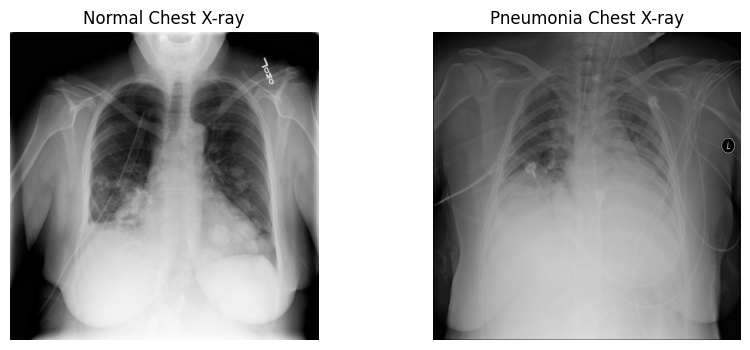

In [18]:
# Pick one normal and one pneumonia patient
normal_id = labels_df[labels_df["Target"] == 0].iloc[0]["patientId"]
pneumonia_id = labels_df[labels_df["Target"] == 1].iloc[0]["patientId"]

normal_img = read_dicom_image(normal_id)
pneumonia_img = read_dicom_image(pneumonia_id)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(normal_img, cmap="gray")
plt.title("Normal Chest X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("Pneumonia Chest X-ray")
plt.axis("off")

plt.show()

In [19]:
print("Normal Image Shape:", normal_img.shape)
print("Pneumonia Image Shape:", pneumonia_img.shape)

print("Pixel range (Normal):", normal_img.min(), "to", normal_img.max())
print("Pixel range (Pneumonia):", pneumonia_img.min(), "to", pneumonia_img.max())

Normal Image Shape: (1024, 1024)
Pneumonia Image Shape: (1024, 1024)
Pixel range (Normal): 0 to 245
Pixel range (Pneumonia): 0 to 255


In [20]:
labels_df[labels_df["patientId"] == pneumonia_id]

,patientId,x,y,width,height,Target
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1


In [21]:
labels_df = pd.read_csv(LABELS_PATH)

# Group by patientId and take max Target
image_labels = labels_df.groupby("patientId")["Target"].max().reset_index()

image_labels.head()

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,000924cf-0f8d-42bd-9158-1af53881a557,0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1
3,000fe35a-2649-43d4-b027-e67796d412e0,1
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1


In [22]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    image_labels,
    test_size=0.2,
    random_state=42,
    stratify=image_labels["Target"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 21347
Validation size: 5337


In [23]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [24]:
class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = self.df.loc[idx, "patientId"]
        label = self.df.loc[idx, "Target"]

        dicom_path = os.path.join(self.image_dir, f"{patient_id}.dcm")
        dicom = pydicom.dcmread(dicom_path)
        image = dicom.pixel_array.astype("float32")

        # Normalize pixel range
        image = image / image.max()

        # Convert grayscale → 3 channel
        image = np.stack([image, image, image], axis=-1)

        if self.transforms:
            image = self.transforms(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [25]:
train_dataset = PneumoniaDataset(
    train_df,
    TRAIN_IMG_PATH,
    transforms=train_transforms
)

val_dataset = PneumoniaDataset(
    val_df,
    TRAIN_IMG_PATH,
    transforms=val_transforms
)

In [26]:
BATCH_SIZE = 16  # Safe for T4 + 224x224

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [27]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:5])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: tensor([0., 0., 0., 0., 0.])


In [30]:
from torchvision.models import densenet121, DenseNet121_Weights
from torch.nn import Linear

Linear(in_features=1024, out_features=1000)

weights = DenseNet121_Weights.IMAGENET1K_V1
model = densenet121(weights=weights)

In [31]:
Linear(in_features=1024, out_features=1000)

Linear(in_features=1024, out_features=1000, bias=True)

In [32]:
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)

In [33]:
model = model.to(device)

In [34]:
print(model.classifier)

Linear(in_features=1024, out_features=1, bias=True)


In [35]:
for param in model.features.parameters():
    param.requires_grad = False

In [36]:
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params:,}")
print(f"Total params: {total_params:,}")

Trainable params: 1,025
Total params: 6,954,881


In [37]:
# Count classes
pos_count = train_df["Target"].sum()
neg_count = len(train_df) - pos_count

pos_weight = neg_count / pos_count
pos_weight

np.float64(3.438045738045738)

In [38]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight).to(device)
)

In [39]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

In [41]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [47]:
def compute_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return acc, prec, rec, f1

In [43]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(
        np.array(all_labels),
        np.array(all_preds)
    )

    return epoch_loss, acc, prec, rec, f1

In [44]:
def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(
        np.array(all_labels),
        np.array(all_preds)
    )

    return epoch_loss, acc, prec, rec, f1

In [48]:
EPOCHS = 5
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch(
        model, val_loader, criterion
    )

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Recall: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/pneumonia_detection/models/best_model.pth")
        print("✅ Best model saved")


Epoch [1/5]
Train Loss: 0.8214 | Acc: 0.7278 | Recall: 0.7732 | F1: 0.5614
Val   Loss: 0.8437 | Acc: 0.6500 | Recall: 0.8835 | F1: 0.5321
LR: 0.001
✅ Best model saved

Epoch [2/5]
Train Loss: 0.8213 | Acc: 0.7291 | Recall: 0.7717 | F1: 0.5621
Val   Loss: 0.8318 | Acc: 0.6537 | Recall: 0.8860 | F1: 0.5354
LR: 0.001
✅ Best model saved

Epoch [3/5]
Train Loss: 0.8197 | Acc: 0.7268 | Recall: 0.7657 | F1: 0.5582
Val   Loss: 0.7953 | Acc: 0.7161 | Recall: 0.8028 | F1: 0.5602
LR: 0.001
✅ Best model saved

Epoch [4/5]
Train Loss: 0.8039 | Acc: 0.7348 | Recall: 0.7753 | F1: 0.5685
Val   Loss: 0.8272 | Acc: 0.6725 | Recall: 0.8636 | F1: 0.5429
LR: 0.001

Epoch [5/5]
Train Loss: 0.8073 | Acc: 0.7353 | Recall: 0.7728 | F1: 0.5682
Val   Loss: 0.7991 | Acc: 0.7491 | Recall: 0.7388 | F1: 0.5701
LR: 0.001


In [49]:
model.load_state_dict(
    torch.load("/content/pneumonia_detection/models/best_model.pth", map_location=device)
)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [50]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [51]:
from sklearn.metrics import confusion_matrix, classification_report

preds = (all_probs > 0.5).astype(int)
cm = confusion_matrix(all_labels, preds)
cm

array([[2857, 1278],
       [ 237,  965]])

In [52]:
print(classification_report(all_labels, preds, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       0.92      0.69      0.79      4135
   Pneumonia       0.43      0.80      0.56      1202

    accuracy                           0.72      5337
   macro avg       0.68      0.75      0.68      5337
weighted avg       0.81      0.72      0.74      5337



In [53]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8256585658324397


GRAD CAM

In [54]:
!pip install -q grad-cam

In [55]:
import cv2
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

In [56]:
model.load_state_dict(
    torch.load("/content/pneumonia_detection/models/best_model.pth", map_location=device)
)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [57]:
target_layers = [model.features.denseblock4]

In [58]:
# pick a pneumonia case from validation set
pneumonia_sample = val_df[val_df["Target"] == 1].iloc[0]
patient_id = pneumonia_sample["patientId"]
true_label = pneumonia_sample["Target"]

print("Patient ID:", patient_id)

Patient ID: 6df264b0-ab7f-471c-b371-7c4018fb43a4


In [59]:
import pydicom

dicom_path = os.path.join(TRAIN_IMG_PATH, f"{patient_id}.dcm")
dicom = pydicom.dcmread(dicom_path)
image = dicom.pixel_array.astype("float32")

# normalize
image_norm = image / image.max()

# convert to 3-channel
image_3ch = np.stack([image_norm]*3, axis=-1)

# resize for model
image_resized = cv2.resize(image_3ch, (224, 224))

# tensor
input_tensor = torch.tensor(image_resized).permute(2,0,1).unsqueeze(0).to(device)

In [62]:
for param in model.features.parameters():
    param.requires_grad = True

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [63]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features.norm5]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [64]:
grayscale_cam = cam(input_tensor=input_tensor)[0]

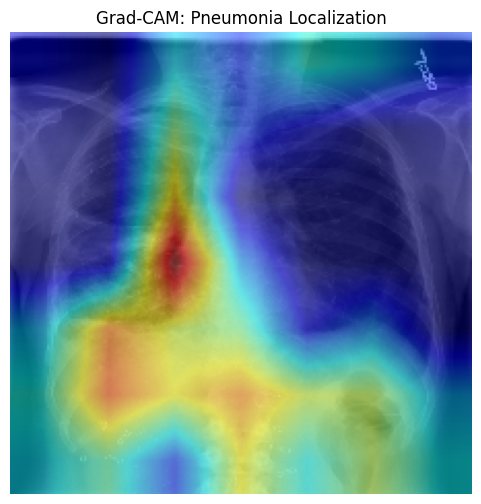

In [65]:
visualization = show_cam_on_image(
    image_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("Grad-CAM: Pneumonia Localization")
plt.axis("off")
plt.show()

Testing on multiple images

In [66]:
for param in model.features.parameters():
    param.requires_grad = True

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [67]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features.norm5]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [68]:
import pydicom
import cv2

def load_preprocess_dicom(patient_id):
    dicom_path = os.path.join(TRAIN_IMG_PATH, f"{patient_id}.dcm")
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array.astype("float32")

    image_norm = image / image.max()
    image_3ch = np.stack([image_norm]*3, axis=-1)
    image_resized = cv2.resize(image_3ch, (224, 224))

    input_tensor = torch.tensor(image_resized).permute(2,0,1).unsqueeze(0).to(device)

    return image_resized, input_tensor

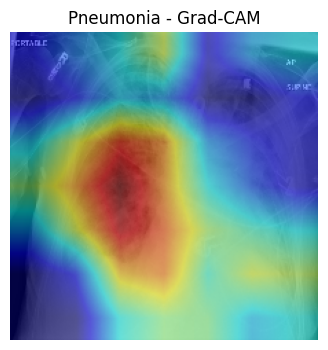

Saved: /content/pneumonia_detection/outputs/gradcam/b34524bc-e812-4067-a0e8-bd7185bfb814_Pneumonia.png


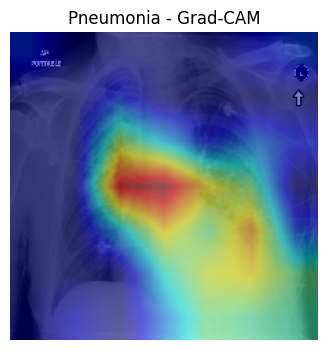

Saved: /content/pneumonia_detection/outputs/gradcam/3c0f1edd-10c2-46da-a01c-a151aa88f2df_Pneumonia.png


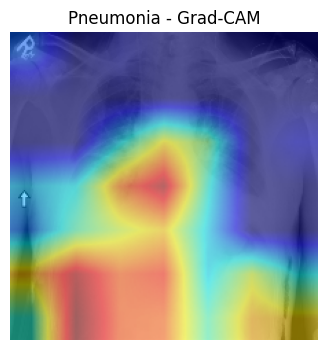

Saved: /content/pneumonia_detection/outputs/gradcam/aa02e36b-226b-454b-8d8a-66e4ada01d99_Pneumonia.png


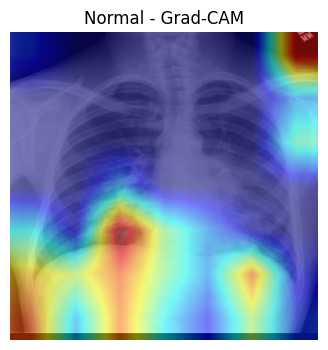

Saved: /content/pneumonia_detection/outputs/gradcam/50db214c-aeb4-4798-b35b-e821b7f6c7fd_Normal.png


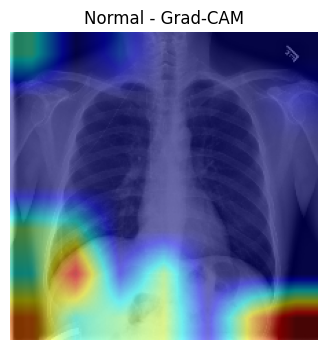

Saved: /content/pneumonia_detection/outputs/gradcam/adfda830-4f01-47d0-adad-0f749cbe68ae_Normal.png


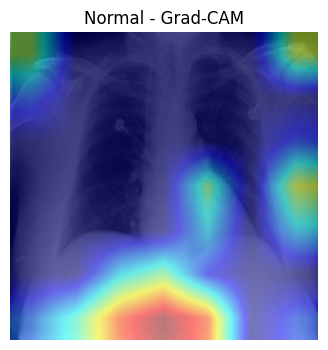

Saved: /content/pneumonia_detection/outputs/gradcam/48fe3b45-4f82-42ef-8175-5e2eb1384cf3_Normal.png


In [69]:
import matplotlib.pyplot as plt

os.makedirs("/content/pneumonia_detection/outputs/gradcam", exist_ok=True)

samples = pd.concat([
    val_df[val_df["Target"] == 1].sample(3, random_state=42),
    val_df[val_df["Target"] == 0].sample(3, random_state=42)
])

for idx, row in samples.iterrows():
    patient_id = row["patientId"]
    label = "Pneumonia" if row["Target"] == 1 else "Normal"

    image_resized, input_tensor = load_preprocess_dicom(patient_id)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        image_resized,
        grayscale_cam,
        use_rgb=True
    )

    save_path = f"/content/pneumonia_detection/outputs/gradcam/{patient_id}_{label}.png"
    cv2.imwrite(save_path, cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))

    plt.figure(figsize=(4,4))
    plt.imshow(visualization)
    plt.title(f"{label} - Grad-CAM")
    plt.axis("off")
    plt.show()

    print("Saved:", save_path)

Enchancing the GRAD CAM

In [70]:
THRESHOLD = 0.5

In [71]:
def predict_pneumonia(model, input_tensor):
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output).item()
    return prob

Patient: b34524bc-e812-4067-a0e8-bd7185bfb814 | Prediction: Pneumonia | Prob: 0.874


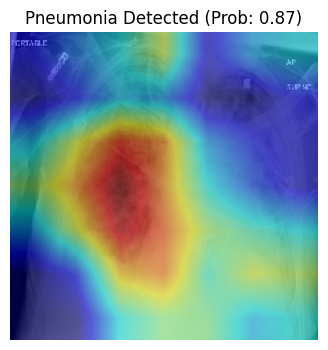

✅ Grad-CAM generated & saved

Patient: 3c0f1edd-10c2-46da-a01c-a151aa88f2df | Prediction: Pneumonia | Prob: 0.540


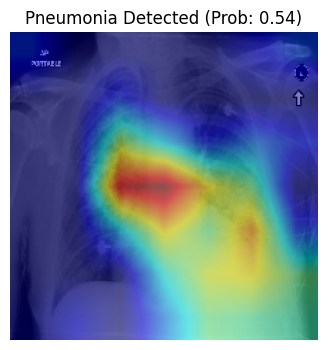

✅ Grad-CAM generated & saved

Patient: aa02e36b-226b-454b-8d8a-66e4ada01d99 | Prediction: Pneumonia | Prob: 0.505


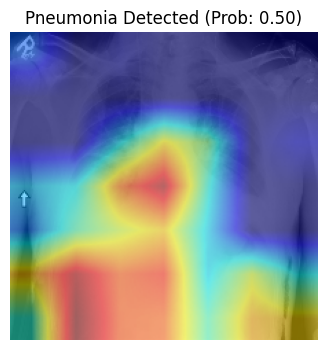

✅ Grad-CAM generated & saved

Patient: 50db214c-aeb4-4798-b35b-e821b7f6c7fd | Prediction: Normal | Prob: 0.281
 Normal detected → Grad-CAM skipped

Patient: adfda830-4f01-47d0-adad-0f749cbe68ae | Prediction: Normal | Prob: 0.153
 Normal detected → Grad-CAM skipped

Patient: 48fe3b45-4f82-42ef-8175-5e2eb1384cf3 | Prediction: Normal | Prob: 0.201
 Normal detected → Grad-CAM skipped



In [72]:
for idx, row in samples.iterrows():
    patient_id = row["patientId"]

    image_resized, input_tensor = load_preprocess_dicom(patient_id)

    # 🔹 Step 1: Predict
    prob = predict_pneumonia(model, input_tensor)
    prediction = "Pneumonia" if prob >= THRESHOLD else "Normal"

    print(f"Patient: {patient_id} | Prediction: {prediction} | Prob: {prob:.3f}")

    #  DO NOT generate Grad-CAM for Normal
    if prediction == "Normal":
        print(" Normal detected → Grad-CAM skipped\n")
        continue

    # Generate Grad-CAM ONLY for Pneumonia
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        image_resized,
        grayscale_cam,
        use_rgb=True
    )

    save_path = f"/content/pneumonia_detection/outputs/gradcam/{patient_id}_Pneumonia.png"
    cv2.imwrite(save_path, cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))

    plt.figure(figsize=(4,4))
    plt.imshow(visualization)
    plt.title(f"Pneumonia Detected (Prob: {prob:.2f})")
    plt.axis("off")
    plt.show()

    print("✅ Grad-CAM generated & saved\n")

Enchance the threshold value

In [73]:
CONF_THRESHOLD = 0.6

In [74]:
def predict_pneumonia(model, input_tensor):
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output).item()
    return prob

In [75]:
for param in model.features.parameters():
    param.requires_grad = True

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [76]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features.norm5]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

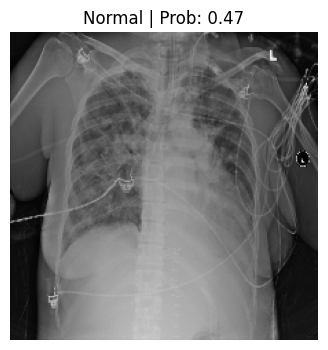

ℹ️ Normal detected → Grad-CAM not generated



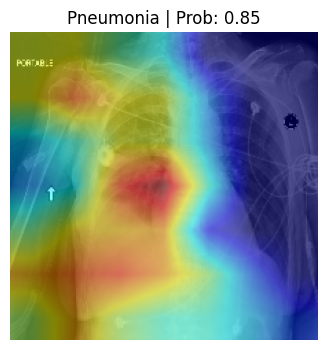

✅ Grad-CAM shown (not saved)



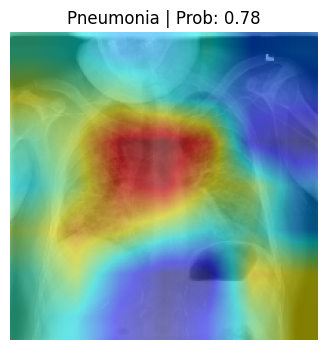

✅ Grad-CAM shown (not saved)



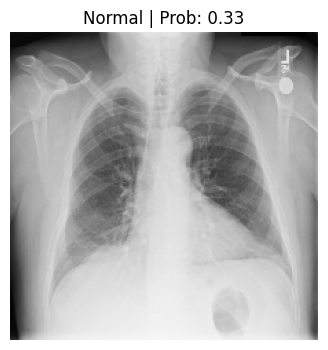

ℹ️ Normal detected → Grad-CAM not generated



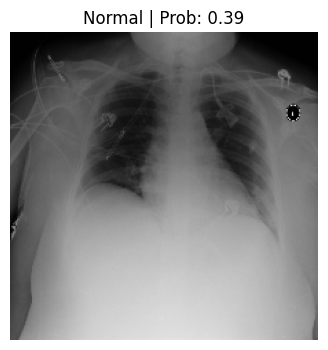

ℹ️ Normal detected → Grad-CAM not generated



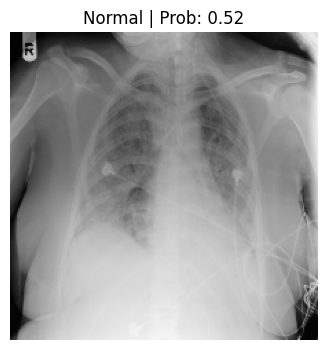

ℹ️ Normal detected → Grad-CAM not generated



In [77]:
import matplotlib.pyplot as plt

# take a mix of samples
samples = pd.concat([
    val_df[val_df["Target"] == 1].sample(3, random_state=1),
    val_df[val_df["Target"] == 0].sample(3, random_state=1)
])

for _, row in samples.iterrows():
    patient_id = row["patientId"]

    image_resized, input_tensor = load_preprocess_dicom(patient_id)

    prob = predict_pneumonia(model, input_tensor)
    prediction = "Pneumonia" if prob >= CONF_THRESHOLD else "Normal"

    # 🔹 NORMAL CASE
    if prediction == "Normal":
        plt.figure(figsize=(4,4))
        plt.imshow(image_resized)
        plt.title(f"Normal | Prob: {prob:.2f}")
        plt.axis("off")
        plt.show()

        print("ℹ️ Normal detected → Grad-CAM not generated\n")
        continue

    # 🔥 HIGH-CONFIDENCE PNEUMONIA → Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        image_resized,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(4,4))
    plt.imshow(visualization)
    plt.title(f"Pneumonia | Prob: {prob:.2f}")
    plt.axis("off")
    plt.show()

    print("✅ Grad-CAM shown (not saved)\n")

In [78]:
import os
import cv2

SAVE_DIR = "/content/pneumonia_detection/outputs/gradcam"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_gradcam(patient_id, visualization, prob):
    save_path = f"{SAVE_DIR}/{patient_id}_Pneumonia_{prob:.2f}.png"
    cv2.imwrite(save_path, cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
    print("💾 Saved:", save_path)

In [79]:
# ONLY call this when you explicitly want to save
save_gradcam(patient_id, visualization, prob)

💾 Saved: /content/pneumonia_detection/outputs/gradcam/fc16f271-8405-4020-b564-bc84696bed88_Pneumonia_0.52.png
